# Ball & Beam: PID Controller Design

Key Python commands used in this tutorial are:
[`control.TransferFunction`](https://python-control.readthedocs.io/en/latest/generated/control.TransferFunction.html),
[`control.step_response`](https://python-control.readthedocs.io/en/latest/generated/control.step_response.html),
[`control.feedback`](https://python-control.readthedocs.io/en/latest/generated/control.feedback.html)

The open-loop transfer function of the plant for the ball and beam experiment is given below:

$$ P(s) = \frac{R(s)}{\Theta(s)} = -\frac{mgd}{L\left(\frac{J}{R^2}+m\right)}\frac{1}{s^2} \qquad [ \frac{m}{rad} ] $$

The design criteria for this problem are:

* Settling time less than 3 seconds
* Overshoot less than 5%

To see the derivation of the equations for this problem refer to the [Ball & Beam: System Modeling](BallBeam_SystemModeling.ipynb) page.

## Closed-loop representation

The block diagram for this example with a controller and unity feedback of the ball's position is shown below:

![feedback_ball.png](figures/feedback_ball.png)

First, we will study the response of the system shown above when a proportional controller is used. Then, derivative and/or integral control will be added if necessary.

Recall, that the transfer function for a PID controller is:

$$ C(s) = K_p + \frac{K_i}{s} + K_d s = \frac{K_d s^2 + K_p s + K_i}{s} $$

## Proportional control

The closed-loop transfer function for proportional control with a proportional gain (Kp) equal to 1, can be modeled by copying the following lines of Python code into a new code cell.



In [1]:
import control
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    rc={
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "figure.figsize": (4 * 1.618, 4),
        "figure.dpi": 200,
    }
)

m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
s = control.TransferFunction.s
P_ball = -m * g * d / L / (J / R**2 + m) / s**2

Kp = 1
C = Kp
sys_cl = control.feedback(C * P_ball, 1)

Now, we can model the system's response to a step input of 0.25 m. Add the following line of code to your code cell and run it. You should get the following output:



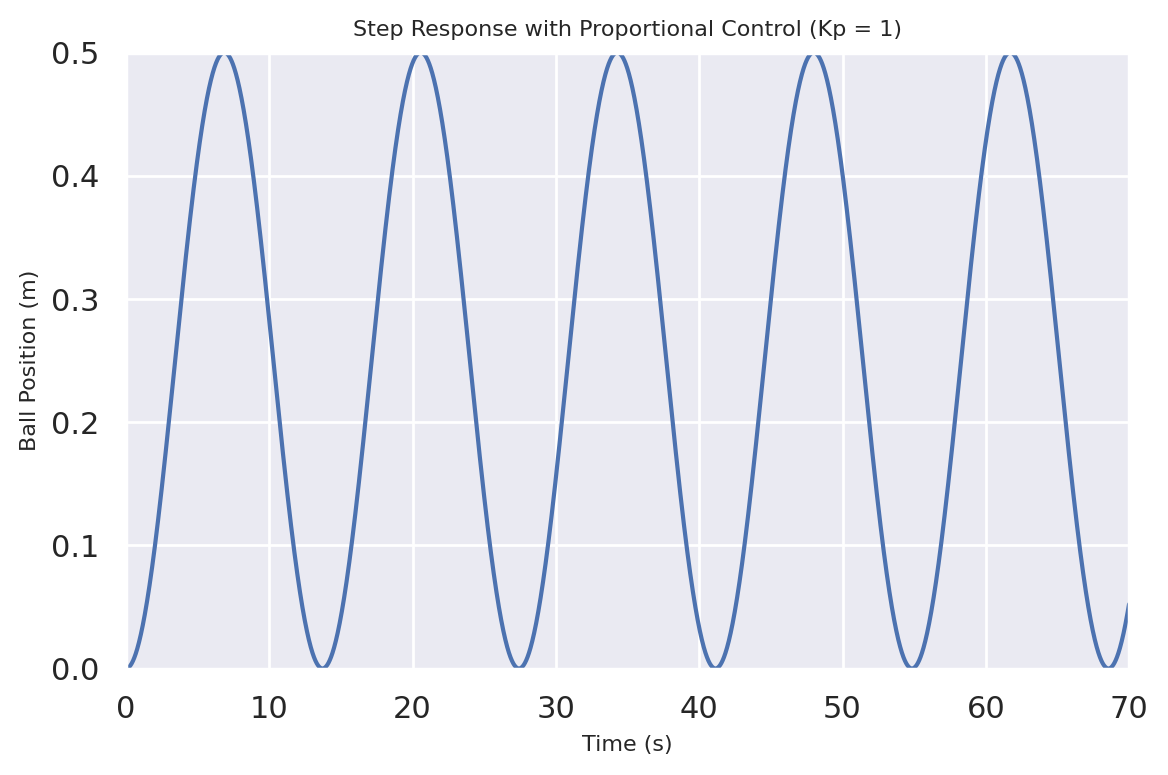

In [2]:
t = np.arange(0, 70, 0.01)
T, yout = control.step_response(0.25 * sys_cl, T=t)
plt.plot(T, yout)
plt.axis([0, 70, 0, 0.5])
plt.title("Step Response with Proportional Control (Kp = 1)")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

As you can see, the system remains marginally stable with the addition of a proportional gain. Try changing the value of Kp and note that the system remains unstable.

## Proportional-derivative control

Now, we will add a derivative term to the controller. Copy the following lines of code to your code cell and run it to view the system's response to this control method. Your plot should be similar to the following:



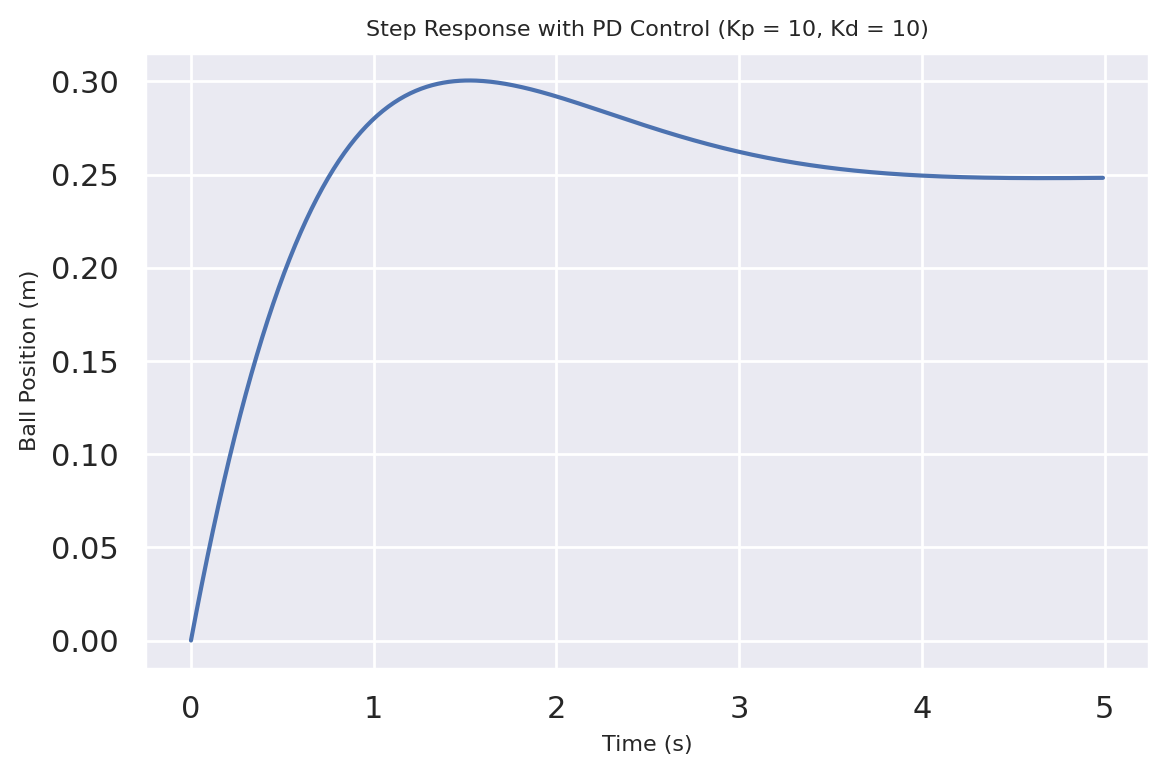

In [3]:
Kp = 10
Kd = 10
C = Kp + Kd * s
sys_cl = control.feedback(C * P_ball, 1)

t = np.arange(0, 5, 0.01)
T, yout = control.step_response(0.25 * sys_cl, T=t)
plt.plot(T, yout)
plt.title("Step Response with PD Control (Kp = 10, Kd = 10)")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

Now the system is stable but the overshoot is much too high and the settling time needs to go down a bit. From the PID tutorial page in the section on characteristics of P, I, and D controllers, we see that by increasing Kd we can lower the overshoot and decrease the settling time slightly. Therefore, make Kd = 20 in your code cell and run it again. Your output should be:



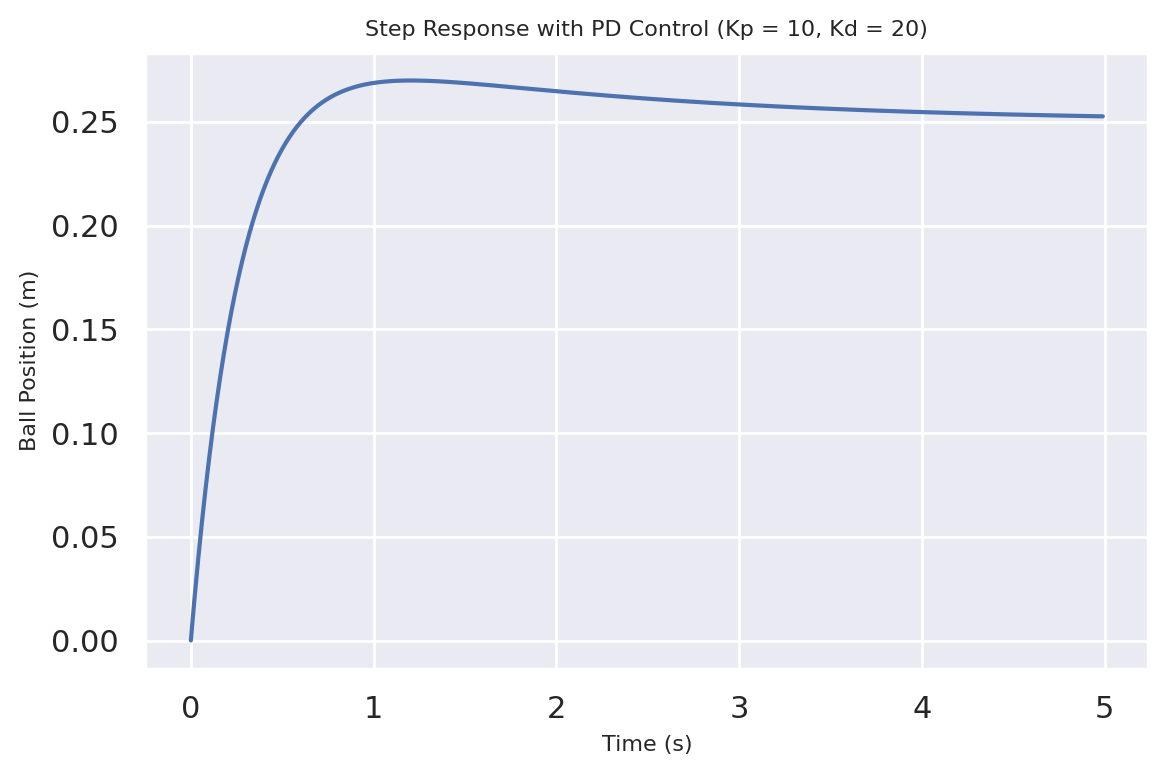

In [4]:
Kp = 10
Kd = 20
C = Kp + Kd * s
sys_cl = control.feedback(C * P_ball, 1)
t = np.arange(0, 5, 0.01)
T, yout = control.step_response(0.25 * sys_cl, T=t)
plt.plot(T, yout)
plt.title("Step Response with PD Control (Kp = 10, Kd = 20)")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

The overshoot criterion is met but the settling time needs to come down a bit. To decrease the settling time we may try increasing the Kp slightly to increase the rise time. The derivative gain (Kd) can also be increased to take off some of the overshoot that increasing Kp will cause. After playing with the gains a bit, the following step response plot can be achieved with Kp = 15 and Kd = 40:



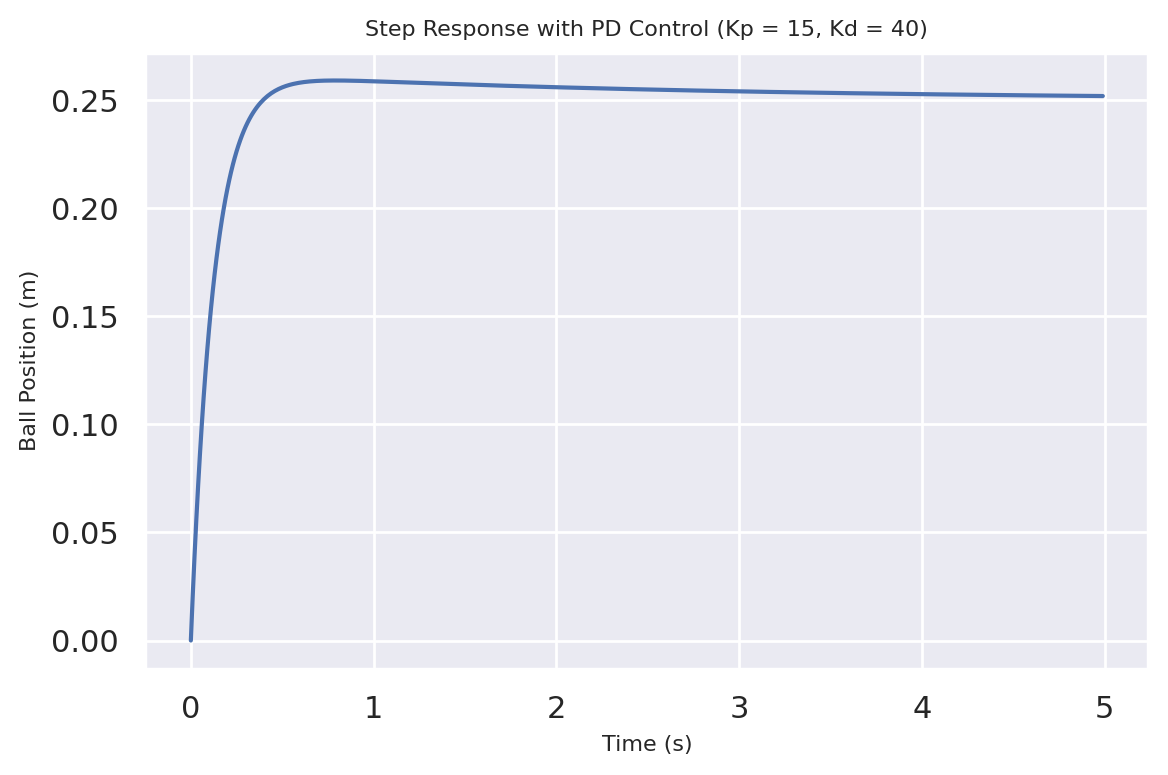

In [5]:
Kp = 15
Kd = 40
C = Kp + Kd * s
sys_cl = control.feedback(C * P_ball, 1)
t = np.arange(0, 5, 0.01)
T, yout = control.step_response(0.25 * sys_cl, T=t)
plt.plot(T, yout)
plt.title("Step Response with PD Control (Kp = 15, Kd = 40)")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

As you can see from the above plot all the control objectives have been met without the use of an integral controller (settling time for this example is considered achieved when the response is less than 2% of its final value). Remember, that for a control problem there is usually more than one solution for the problem.

